In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120

## Load LFW (min_faces_per_person=50) and flatten

In [2]:
lfw = fetch_lfw_people(min_faces_per_person=50, resize=0.4, color=False)
X_images = lfw.images                 # (n_samples, h, w)
X = lfw.data.astype(np.float32)       # (n_samples, h*w)
y = lfw.target                        # integer labels
target_names = lfw.target_names       # label -> name mapping
h, w = lfw.images.shape[1:3]

## Stratified split: 60% train / 15% val / 25% test
We do it in two stages to preserve class balance with a fixed seed:
1. Train+Val vs Test (75/25)
2. Train vs Val (80/20) → overall 60/15/25.

In [3]:
X_trval, X_te, y_trval, y_te = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_trval, y_trval, test_size=0.20, stratify=y_trval, random_state=RANDOM_STATE
)

## 4) Preprocessing
- **Standardize** using **TRAIN** stats only.
- **ℓ2-normalize rows**

In [4]:
def fit_standardize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0, ddof=1)
    sigma[sigma < 1e-8] = 1e-8
    return mu, sigma

def apply_standardize(X, mu, sigma):
    return (X - mu) / sigma

def l2_normalize_rows(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms < 1e-12] = 1e-12
    return X / norms

# Compute TRAIN stats and standardize all splits
mu_tr, sig_tr = fit_standardize(X_tr)
Xtr_std = apply_standardize(X_tr, mu_tr, sig_tr)
Xval_std = apply_standardize(X_val, mu_tr, sig_tr)
Xte_std  = apply_standardize(X_te,  mu_tr, sig_tr)

# ℓ2-normalize rows 
Xtr_proc = l2_normalize_rows(Xtr_std)
Xval_proc = l2_normalize_rows(Xval_std)
Xte_proc  = l2_normalize_rows(Xte_std)

## PCA via SVD 
1. Fit PCA on centered TRAIN data 
2. pick k from cumulative variance ratio.
3. Project **train/val/test** with the top-\(k\) components.

In [5]:
def pca_fit_svd(X_train_centered):
    U, S, Vt = np.linalg.svd(X_train_centered, full_matrices=False)
    explained_variance = (S**2) / (X_train_centered.shape[0] - 1)
    explained_variance_ratio = explained_variance / np.sum(explained_variance)
    return Vt, S, explained_variance, explained_variance_ratio

def pca_choose_k_from_ratio(evr, target_ratio=0.95):
    cumulative_evr = np.cumsum(evr)
    k = np.searchsorted(cumulative_evr,target_ratio)
    return k

def pca_project_splits(Xtr_std, Xval_std, Xte_std, target_ratio=0.95):
    # Center TRAIN 
    mu = np.mean(Xtr_std, axis = 0)
    Xtr_centered = Xtr_std - mu
    Xval_centered = Xval_std - mu
    Xte_centered = Xte_std - mu
    Vt, S, explained_variance, explained_variance_ratio = pca_fit_svd(Xtr_centered)
    k = pca_choose_k_from_ratio(explained_variance_ratio,target_ratio)
    V_k = Vt[:k].T
    Z_tr = Xtr_centered@V_k
    Z_val = Xval_centered@V_k
    Z_te = Xte_centered@V_k
    return Z_tr, Z_val, Z_te, V_k, k

## CRC (Collaborative Representation Classifier) 

In [6]:
def crc_precompute(D, lam):
    inverse = D.T@D + lam * np.identity(D.T.shape[0])
    P = np.linalg.solve(inverse,D.T)
    return P

def crc_predict_one(P, D, y_vec, y_tr, classes):
    alpha = P@y_vec
    residuals = []
    for c in classes:
        mask = (y_tr == c)
        D_c = D[:, mask]    
        alpha_c = alpha[mask]
        residual = np.linalg.norm(y_vec - D_c@alpha_c)**2
        residuals.append(residual)
    prediction = classes[np.argmin(residuals)]
    return prediction

def crc_predict_set(P, D, X_set, y_tr, classes):
    prediction_set = []
    for x in X_set:
        prediction_set.append(crc_predict_one(P,D,x,y_tr,classes))
    return prediction_set

## Baseline: CRC without PCA (tune λ on validation)
1. Build `D` from **Xtr_proc** 
2. Try a grid of λ values.
3. Pick the best λ by **validation accuracy**.
4. Retrain CRC on **train+val** with that λ, then evaluate once on **test**.

In [7]:
lambdas = [1e-3, 1e-2, 1e-1, 1, 10]
D = Xtr_proc.T   # dictionary (d, n_tr)
classes = np.unique(y_tr)

best_no_pca = None
best_lam_no_pca = None

for lam in lambdas:
    P = crc_precompute(D, lam)
    preds_val = crc_predict_set(P, D, Xval_proc, y_tr, classes)
    acc_val = accuracy_score(y_val, preds_val)
    print(f"[CRC no PCA] λ={lam:>6g} | Val Acc={acc_val:.4f}")
    if (best_no_pca is None) or (acc_val > best_no_pca['val_acc']):
            best_no_pca = {'val_acc': acc_val}
            best_lam_no_pca = lam

print(f"Best (no PCA): λ={best_lam_no_pca} | Val Acc={best_no_pca['val_acc']:.4f}")

Xtrval_proc = l2_normalize_rows(apply_standardize(np.vstack([X_tr, X_val]), mu_tr, sig_tr))
y_trval = np.hstack([y_tr, y_val])
D_trval = Xtrval_proc.T
P_best = crc_precompute(D_trval, best_lam_no_pca)
test_preds_no_pca = crc_predict_set(P_best, D_trval, Xte_proc, y_trval, np.unique(y_trval))
test_acc_no_pca = accuracy_score(y_te, test_preds_no_pca)
print(f"[CRC no PCA] Retrained on TR+VAL → Test Acc={test_acc_no_pca:.4f}")

[CRC no PCA] λ= 0.001 | Val Acc=0.4274
[CRC no PCA] λ=  0.01 | Val Acc=0.4829
[CRC no PCA] λ=   0.1 | Val Acc=0.5085
[CRC no PCA] λ=     1 | Val Acc=0.4359
[CRC no PCA] λ=    10 | Val Acc=0.3462
Best (no PCA): λ=0.1 | Val Acc=0.5085
[CRC no PCA] Retrained on TR+VAL → Test Acc=0.4821


## CRC with PCA (tune variance ratio and λ on validation)

1. Fit PCA on **TRAIN** to get components and EVR.
2. Try a small set of target ratios, e.g. `[0.90, 0.95, 0.99]`.
3. For each ratio, project train/val/test to **Z**-space (top-\(k\) components).
4. ℓ2-normalize rows, build dictionary `Dk` from `Z_tr.T`.
5. Tune λ on **val**; pick best ratio and λ.
6. Retrain PCA+CRC on **train+val** with best settings; test once.

In [8]:
ratios = [0.90, 0.95, 0.99]
lambdas = [1e-3, 1e-2, 1e-1, 1, 10]

Xtr_centered = Xtr_std - Xtr_std.mean(axis=0)
components, S, ev, evr = pca_fit_svd(Xtr_centered)

best_pca = None
best_params_pca = None

for ratio in ratios:
    Z_tr, Z_val, Z_te, comps_k, k = pca_project_splits(Xtr_std, Xval_std, Xte_std, target_ratio=ratio)
    Z_tr = l2_normalize_rows(Z_tr); Z_val = l2_normalize_rows(Z_val); Z_te = l2_normalize_rows(Z_te)
    Dk = Z_tr.T
    for lam in lambdas:
        Pk = crc_precompute(Dk, lam)
        preds_val = crc_predict_set(Pk, Dk, Z_val, y_tr, classes)
        acc_val = accuracy_score(y_val, preds_val)
        print(f"[CRC + PCA] ratio={ratio:.2f} (k={k}) λ={lam:>6g} | Val Acc={acc_val:.4f}")
        if (best_pca is None) or (acc_val > best_pca['val_acc']):
            best_pca = {'val_acc': acc_val, 'lam': lam, 'ratio': ratio, 'k': k}
            best_params_pca = (ratio, k, lam)

ratio_star, k_star, lam_star = best_params_pca
# (Rebuild Z_tr, Z_val, Z_te for the chosen k_star) and stack TR+VAL before final CRC
Xtrval_std = np.vstack([Xtr_std, Xval_std])
y_trval = np.hstack([y_tr, y_val])
Z_trval, Z_val, Z_te, comps_k, k = pca_project_splits(Xtrval_std, Xval_std, Xte_std, ratio_star)
Z_trval = l2_normalize_rows(Z_trval)
Z_te = l2_normalize_rows(Z_te)
D_trval = Z_trval.T
P_best = crc_precompute(D_trval, lam_star)
test_preds_pca = crc_predict_set(P_best, D_trval, Z_te, y_trval, classes)
test_acc_pca = accuracy_score(y_te, test_preds_pca)
print(f"[CRC with PCA] Retrained on TR+VAL → Test Acc={test_acc_pca:.4f}")

[CRC + PCA] ratio=0.90 (k=81) λ= 0.001 | Val Acc=0.4444
[CRC + PCA] ratio=0.90 (k=81) λ=  0.01 | Val Acc=0.4444
[CRC + PCA] ratio=0.90 (k=81) λ=   0.1 | Val Acc=0.4444
[CRC + PCA] ratio=0.90 (k=81) λ=     1 | Val Acc=0.4316
[CRC + PCA] ratio=0.90 (k=81) λ=    10 | Val Acc=0.3504
[CRC + PCA] ratio=0.95 (k=154) λ= 0.001 | Val Acc=0.4744
[CRC + PCA] ratio=0.95 (k=154) λ=  0.01 | Val Acc=0.4744
[CRC + PCA] ratio=0.95 (k=154) λ=   0.1 | Val Acc=0.4744
[CRC + PCA] ratio=0.95 (k=154) λ=     1 | Val Acc=0.4402
[CRC + PCA] ratio=0.95 (k=154) λ=    10 | Val Acc=0.3504
[CRC + PCA] ratio=0.99 (k=373) λ= 0.001 | Val Acc=0.5000
[CRC + PCA] ratio=0.99 (k=373) λ=  0.01 | Val Acc=0.4915
[CRC + PCA] ratio=0.99 (k=373) λ=   0.1 | Val Acc=0.4786
[CRC + PCA] ratio=0.99 (k=373) λ=     1 | Val Acc=0.4316
[CRC + PCA] ratio=0.99 (k=373) λ=    10 | Val Acc=0.3462
[CRC with PCA] Retrained on TR+VAL → Test Acc=0.5051


## Confusion matrix plots

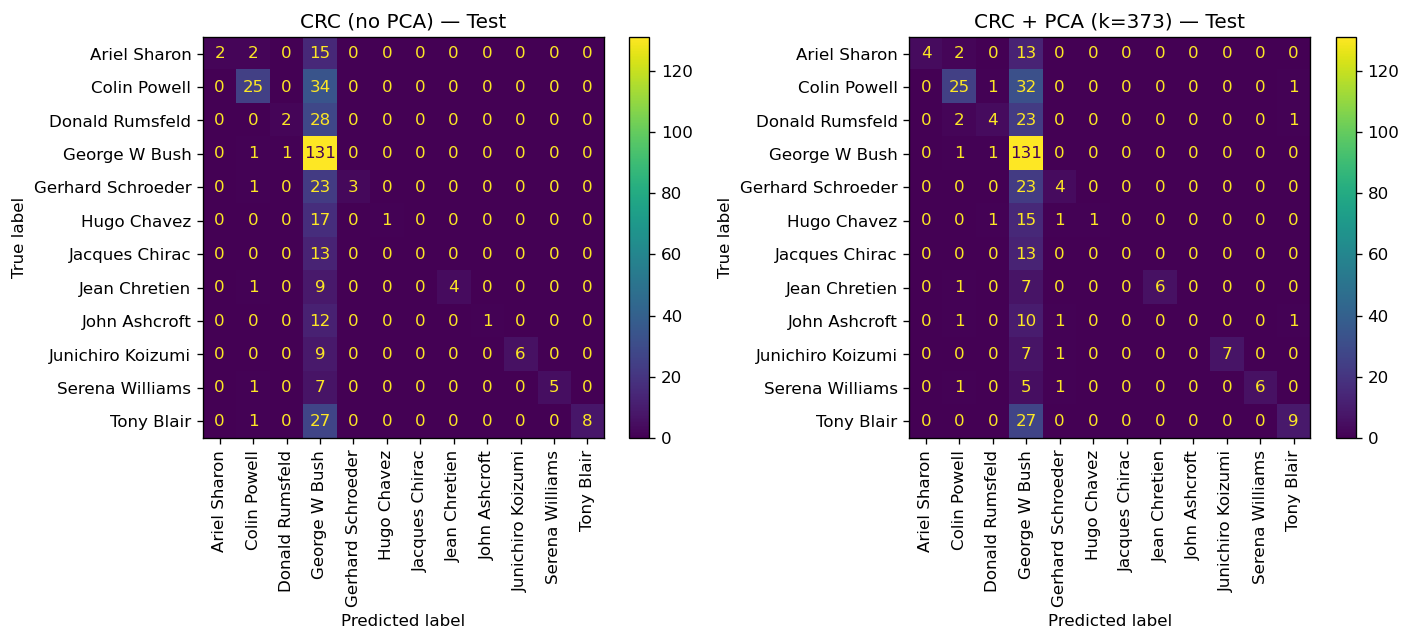

In [9]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(1,2, figsize=(12,5))
ConfusionMatrixDisplay.from_predictions(y_te, test_preds_no_pca, display_labels=target_names, xticks_rotation=90, ax=ax[0])
ax[0].set_title('CRC (no PCA) — Test')
ConfusionMatrixDisplay.from_predictions(y_te, test_preds_pca, display_labels=target_names, xticks_rotation=90, ax=ax[1])
ax[1].set_title(f'CRC + PCA (k={best_pca["k"]}) — Test')
plt.tight_layout(); plt.show()